# 02 — DeMemte VQSA estricto

Entrenamiento y evaluación end-to-end de la arquitectura VQSA: ResNet18 congelado, codebook VQ, fusión `concat(z, zq)` y self-attention. Los checkpoints legacy attractor/gate no se cargan en esta versión.

In [1]:
import sys, os
from pathlib import Path
ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'src' / 'dememte').exists():
    ROOT = ROOT.parent
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
print('repo root:', ROOT)

repo root: /home/nakato/projects/Dememte


In [2]:
import json
from dataclasses import asdict

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from dememte.config import E5Config, resolve_data_dir
from dememte.data import build_loaders, seed_everything
from dememte.models import make_dememte_e5
from dememte.training import train_dememte_vqsa
from dememte.evaluation import evaluate_dememte_suite, signal_curve_rows
from dememte.io import save_checkpoint, load_checkpoint, write_json, write_csv, ensure_dir

RUN_TRAINING = True

cfg = E5Config()
cfg.data_dir = resolve_data_dir(cfg)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
OUT = ensure_dir(ROOT / 'notebooks' / '02_e5_winner' / 'out')
CKPT = OUT / 'vqsa_best.pt'
seed_everything(cfg.seed)
print(json.dumps(asdict(cfg), indent=2))

{
  "data_dir": "/home/nakato/projects/Dememte/experiments/data",
  "num_classes": 102,
  "batch_size": 16,
  "num_workers": 2,
  "device": "cuda",
  "val_ratio": 0.2,
  "split_seed": 42,
  "benchmark_protocol": "historical_trainval_resplit",
  "lr_vq": 0.0003,
  "lr_cls": 0.0001,
  "weight_decay": 0.0001,
  "epochs_vqsa_max": 10,
  "early_stop_patience": 3,
  "early_stop_min_delta": 0.0001,
  "scheduler_factor": 0.5,
  "scheduler_patience": 2,
  "latent_dim": 256,
  "num_embeddings": 1024,
  "commitment_cost": 0.25,
  "vq_temperature": 1.0,
  "vq_weight": 1.0,
  "vqsa_heads": 4,
  "vqsa_layers": 2,
  "vqsa_dropout": 0.1,
  "vqsa_fusion_mode": "concat",
  "vqsa_use_codebook": true,
  "vqsa_use_self_attention": true,
  "vqsa_train_backbone": false,
  "train_corrupt_prob": 0.7,
  "out_dir": "./out",
  "seed": 42
}


## Datos

In [3]:
tr_loader, va_loader, te_loader, meta = build_loaders(
    data_dir=cfg.data_dir,
    batch_size=cfg.batch_size,
    num_workers=cfg.num_workers,
    val_ratio=cfg.val_ratio,
    split_seed=cfg.split_seed,
    protocol=cfg.benchmark_protocol,
)
print(meta)

{'protocol': 'historical_trainval_resplit', 'split_seed': 42, 'train_size': 1632, 'val_size': 408, 'test_size': 6149}


## Modelo VQSA

In [4]:
model = make_dememte_e5(cfg, device=device)
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model.parameters())
print(f'params total: {n_total:,} | trainable (post-init): {n_trainable:,}')

params total: 13,464,998 | trainable (post-init): 2,288,486


## Entrenamiento opcional o carga del checkpoint VQSA

In [5]:
if RUN_TRAINING:
    seed_everything(cfg.seed)
    model = make_dememte_e5(cfg, device=device)
    model, best_acc = train_dememte_vqsa(model, tr_loader, va_loader, cfg, device)
    save_checkpoint(model, CKPT, extra={'best_val': best_acc, 'config': asdict(cfg)})
    print(f'saved {CKPT} (best_val={best_acc:.4f})')
else:
    if not CKPT.exists():
        raise FileNotFoundError(f'Missing VQSA checkpoint: {CKPT}. Set RUN_TRAINING=True to train one.')
    payload = load_checkpoint(model, CKPT, device=device, strict=True)
    print('loaded:', CKPT, '| best_val:', payload.get('best_val'))

[VQSA 01] tr_loss=4.5407 tr_acc=0.1360 val_loss=3.3285 val_acc=0.3676 val_vq=0.6731
[VQSA 02] tr_loss=3.0232 tr_acc=0.3860 val_loss=2.3458 val_acc=0.5564 val_vq=0.6698
[VQSA 03] tr_loss=2.3647 tr_acc=0.5309 val_loss=2.0401 val_acc=0.6176 val_vq=0.6509
[VQSA 04] tr_loss=2.0492 tr_acc=0.5965 val_loss=1.8819 val_acc=0.6544 val_vq=0.6164
[VQSA 05] tr_loss=1.7966 tr_acc=0.6670 val_loss=1.8217 val_acc=0.6814 val_vq=0.6098
[VQSA 06] tr_loss=1.5883 tr_acc=0.7004 val_loss=1.7177 val_acc=0.6961 val_vq=0.5747
[VQSA 07] tr_loss=1.5931 tr_acc=0.6958 val_loss=1.5943 val_acc=0.7402 val_vq=0.5811
[VQSA 08] tr_loss=1.4914 tr_acc=0.7240 val_loss=1.6325 val_acc=0.7426 val_vq=0.5437
[VQSA 09] tr_loss=1.3661 tr_acc=0.7619 val_loss=1.6272 val_acc=0.7034 val_vq=0.5369
[VQSA 10] tr_loss=1.2796 tr_acc=0.7969 val_loss=1.5085 val_acc=0.7525 val_vq=0.5327
saved /home/nakato/projects/Dememte/notebooks/02_e5_winner/out/vqsa_best.pt (best_val=0.7525)


## Evaluación clean + corrupt + diagnósticos VQSA

In [6]:
metrics = evaluate_dememte_suite(model, te_loader, device=device, return_predictions=True)
clean_record = metrics.pop('clean_record')
corrupt_records = metrics.pop('corruption_records')

predictions = clean_record.pop('predictions', [])
for rows in corrupt_records.values():
    for rec in rows:
        predictions.extend(rec.pop('predictions', []))

summary = {k: v for k, v in metrics.items() if isinstance(v, (int, float, bool))}
summary.update({'protocol': meta['protocol'], 'split_seed': meta['split_seed'], 'variant': 'vqsa_full'})
write_json(summary, OUT / 'metrics.json')
write_csv(predictions, OUT / 'predictions.csv')
write_csv(signal_curve_rows('vqsa_full', 'DeMemte VQSA', clean_record, corrupt_records), OUT / 'signal_curves.csv')
print(json.dumps(summary, indent=2))

{
  "clean_acc": 0.7360546430313872,
  "corrupt_acc_avg": 0.4957039084946062,
  "corrupt_acc_gaussian_noise": 0.35713124085217113,
  "corrupt_acc_pixel_mask": 0.34054317775248005,
  "corrupt_acc_cutout": 0.6241123217867405,
  "corrupt_acc_blur": 0.6610288935870331,
  "ece_clean": 0.043293373517184416,
  "ece_corrupt_avg": 0.08097687577308249,
  "nll_clean": 0.9759166575692882,
  "nll_corrupt_avg": 1.971521736681943,
  "brier_clean": 0.36549604142895264,
  "brier_corrupt_avg": 0.6422063346534573,
  "vq_loss_clean": 0.526750385761261,
  "vq_loss_corrupt_avg": 0.5796285147468249,
  "codebook_loss_clean": 0.42140036821365356,
  "codebook_loss_corrupt_avg": 0.46370280037323636,
  "commitment_loss_clean": 0.42140036821365356,
  "commitment_loss_corrupt_avg": 0.46370280037323636,
  "dq_mean_clean": 0.42140036821365356,
  "dq_mean_corrupt_avg": 0.46370281527439755,
  "assignment_entropy_clean": 0.162135049700737,
  "assignment_entropy_corrupt_avg": 0.09999787186582883,
  "codebook_perplexity_c

## Curvas VQSA por corrupción/severidad

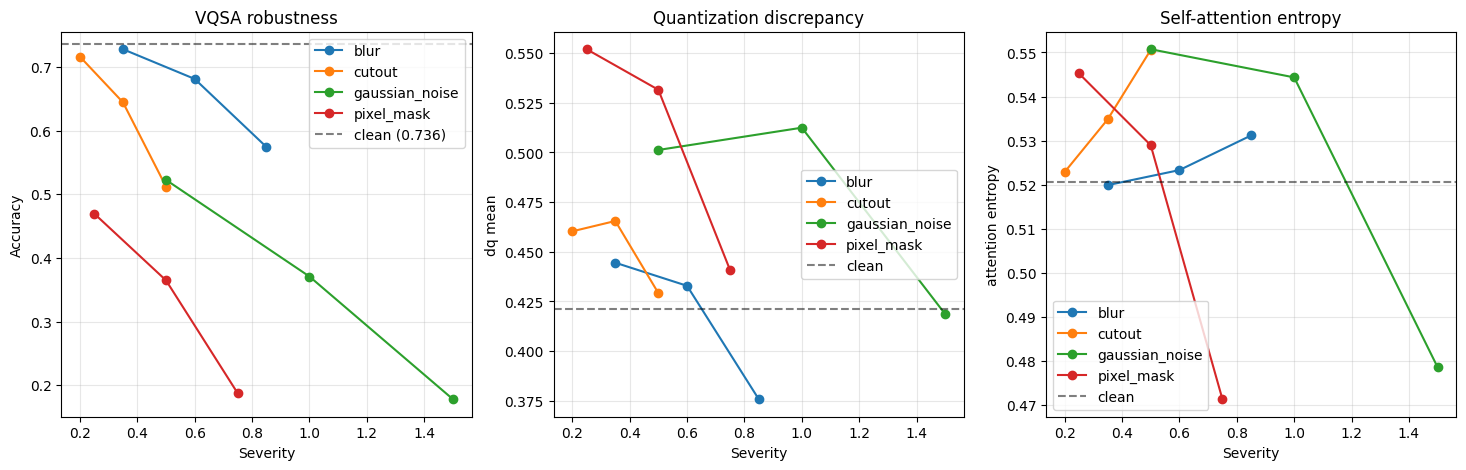

In [7]:
curves = pd.read_csv(OUT / 'signal_curves.csv')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for corr, sub in curves[curves['corruption'] != 'clean'].groupby('corruption'):
    axes[0].plot(sub['severity'], sub['acc'], marker='o', label=corr)
    axes[1].plot(sub['severity'], sub['dq_mean_mean'], marker='o', label=corr)
    axes[2].plot(sub['severity'], sub['attention_entropy_mean'], marker='o', label=corr)
clean_row = curves[curves['corruption'] == 'clean'].iloc[0]
axes[0].axhline(clean_row['acc'], linestyle='--', color='k', alpha=0.5, label=f"clean ({clean_row['acc']:.3f})")
axes[1].axhline(clean_row['dq_mean_mean'], linestyle='--', color='k', alpha=0.5, label='clean')
axes[2].axhline(clean_row['attention_entropy_mean'], linestyle='--', color='k', alpha=0.5, label='clean')
axes[0].set_xlabel('Severity'); axes[0].set_ylabel('Accuracy'); axes[0].set_title('VQSA robustness')
axes[1].set_xlabel('Severity'); axes[1].set_ylabel('dq mean'); axes[1].set_title('Quantization discrepancy')
axes[2].set_xlabel('Severity'); axes[2].set_ylabel('attention entropy'); axes[2].set_title('Self-attention entropy')
for ax in axes: ax.grid(alpha=0.3); ax.legend()
ensure_dir(OUT / 'vqsa_plots')
fig.savefig(OUT / 'vqsa_plots' / 'vqsa_diagnostics.png', dpi=120, bbox_inches='tight')
plt.show()